# Gemma4-E4B
# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [3]:
!nvidia-smi

Fri Jun 19 20:56:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   38C    P0            134W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [1]:
# --- HF Auth ---
import sys
sys.path.append("/home/jovyan") 
from config_hf_token import HF_TOKEN
from huggingface_hub import login
login(token=HF_TOKEN)

# --- Path setup ---
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

# --- Load Gemma model ---
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "google/gemma-4-E4B-it"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
device = model.device

# --- Imports ---
from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.inference_gemma import run_inference_gemma
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"        # experiments/e1/gemma4-12b/outputs/
SEED = 42
SAMPLE_SIZE = 50

# --- Build paired sample (reuses selected_images.json from Qwen runs) ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

config.json:   0%|          | 0.00/5.14k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 50 pairs → 100 images total


In [2]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 3g.40gb
VRAM total: 42.3 GB
VRAM free: 15.9 GB reserved


# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [7]:
# --- Baseline single (like/scroll) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json",
                inference_fn=run_inference_gemma)


📋 Resuming — 100 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 020_correct
⏭ Skipping: 020_incorrect
⏭ Skipping: 021_correct
⏭ Skipping: 021_incorrect
⏭ Skipping: 023_correct
⏭ Skipping: 023_incorrect
⏭ Skipping: 025_correct
⏭ Skipping: 025_incorrect
⏭ Skipping: 026_correct
⏭ Skipping: 026_incorrect
⏭ Skipping: 028_correct
⏭ Skipping: 028_incorrect
⏭ Skipping: 029_correct
⏭ Skipping: 029_incorrect
⏭ Skipping: 030_correct
⏭ Skipping: 030_incorrect
⏭ Skipp

In [8]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,98.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,96.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
2,003_correct,correct,You are shown a social media post.\nYou can ei...,like
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
4,004_correct,correct,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
96,098_correct,correct,You are shown a social media post.\nYou can ei...,like
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
98,100_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [9]:
# --- Baseline single (yes/no) ---
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
                prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",
                inference_fn=run_inference_gemma)

✅ 001_correct → no
✅ 001_incorrect → no
✅ 003_correct → no
✅ 003_incorrect → no
✅ 004_correct → no
✅ 004_incorrect → no
✅ 005_correct → no
✅ 005_incorrect → no
✅ 006_correct → no
✅ 006_incorrect → no
✅ 007_correct → no
✅ 007_incorrect → no
✅ 012_correct → no
✅ 012_incorrect → no
✅ 014_correct → no
✅ 014_incorrect → no
✅ 015_correct → no
✅ 015_incorrect → no
✅ 017_correct → no
✅ 017_incorrect → no
✅ 018_correct → no
✅ 018_incorrect → no
✅ 020_correct → no
✅ 020_incorrect → no
✅ 021_correct → no
✅ 021_incorrect → no
✅ 023_correct → no
✅ 023_incorrect → no
✅ 025_correct → no
✅ 025_incorrect → no
✅ 026_correct → no
✅ 026_incorrect → no
✅ 028_correct → no
✅ 028_incorrect → no
✅ 029_correct → no
✅ 029_incorrect → no
✅ 030_correct → no
✅ 030_incorrect → no
✅ 032_correct → no
✅ 032_incorrect → no
✅ 036_correct → no
✅ 036_incorrect → no
✅ 039_correct → no
✅ 039_incorrect → no
✅ 044_correct → no
✅ 044_incorrect → no
✅ 047_correct → no
✅ 047_incorrect → no
✅ 052_correct → no
✅ 052_incorrect → no


In [10]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,003_correct,correct,You are shown a social media post.\nYou can ei...,no
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,004_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
96,098_correct,correct,You are shown a social media post.\nYou can ei...,no
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
98,100_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [11]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [12]:
# --- Baseline paired A/B ---
run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
                       prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json",
                       inference_fn=run_inference_gemma)


✅ Pair 001 → liked correct (answered A)
✅ Pair 003 → liked correct (answered A)
✅ Pair 004 → liked incorrect (answered A)
✅ Pair 005 → liked correct (answered A)
✅ Pair 006 → liked incorrect (answered A)
✅ Pair 007 → liked correct (answered A)
✅ Pair 012 → liked incorrect (answered A)
✅ Pair 014 → liked incorrect (answered A)
✅ Pair 015 → liked correct (answered A)
✅ Pair 017 → liked correct (answered A)
✅ Pair 018 → liked correct (answered A)
✅ Pair 020 → liked incorrect (answered A)
✅ Pair 021 → liked correct (answered A)
✅ Pair 023 → liked correct (answered A)
✅ Pair 025 → liked correct (answered A)
✅ Pair 026 → liked incorrect (answered A)
✅ Pair 028 → liked incorrect (answered A)
✅ Pair 029 → liked correct (answered A)
✅ Pair 030 → liked correct (answered A)
✅ Pair 032 → liked incorrect (answered A)
✅ Pair 036 → liked incorrect (answered A)
✅ Pair 039 → liked incorrect (answered A)
✅ Pair 044 → liked incorrect (answered A)
✅ Pair 047 → liked correct (answered A)
✅ Pair 052 → liked

In [13]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,54.0
1,liked_incorrect_%,46.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
5,007,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
6,012,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
7,014,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
8,015,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
9,017,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [14]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

In [15]:
correct_base_likes = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base_likes = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"

## Approach 1: like or scroll - single image

In [16]:
# --- Likes only single (like/scroll) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json",
              inference_fn=run_inference_gemma)



✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_10 → like
✅ 032_incorrect_10 → like


In [17]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,99.83
1,like_rate_correct_%,100.00
2,like_rate_incorrect_%,99.67


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,99.0,100.0,98.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [18]:
# --- Likes only single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json",
              inference_fn=run_inference_gemma)



✅ 001_correct_10 → no
✅ 001_incorrect_10 → no
✅ 003_correct_10 → no
✅ 003_incorrect_10 → no
✅ 004_correct_10 → no
✅ 004_incorrect_10 → no
✅ 005_correct_10 → no
✅ 005_incorrect_10 → no
✅ 006_correct_10 → no
✅ 006_incorrect_10 → no
✅ 007_correct_10 → no
✅ 007_incorrect_10 → no
✅ 012_correct_10 → no
✅ 012_incorrect_10 → no
✅ 014_correct_10 → no
✅ 014_incorrect_10 → no
✅ 015_correct_10 → no
✅ 015_incorrect_10 → no
✅ 017_correct_10 → no
✅ 017_incorrect_10 → no
✅ 018_correct_10 → no
✅ 018_incorrect_10 → no
✅ 020_correct_10 → no
✅ 020_incorrect_10 → no
✅ 021_correct_10 → no
✅ 021_incorrect_10 → no
✅ 023_correct_10 → no
✅ 023_incorrect_10 → no
✅ 025_correct_10 → no
✅ 025_incorrect_10 → no
✅ 026_correct_10 → no
✅ 026_incorrect_10 → no
✅ 028_correct_10 → no
✅ 028_incorrect_10 → no
✅ 029_correct_10 → no
✅ 029_incorrect_10 → no
✅ 030_correct_10 → no
✅ 030_incorrect_10 → no
✅ 032_correct_10 → no
✅ 032_incorrect_10 → no
✅ 036_correct_10 → no
✅ 036_incorrect_10 → no
✅ 039_correct_10 → no
✅ 039_incorr

In [19]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,0.0,0.0,0.0
1,100,100.0,0.0,0.0,0.0
2,1000,100.0,0.0,0.0,0.0
3,10000,100.0,0.0,0.0,0.0
4,100000,100.0,0.0,0.0,0.0
5,1000000,100.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [20]:
import time
start = time.time()

# --- Likes only paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base_likes, incorrect_base_likes, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json",
                      inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked correct (answered A)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 028_correct0_vs_incorrect0 → liked incorrect (answered A)


In [21]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 10m 45s
⏱ Average per pair: 0.26s


In [22]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,49.84
1,overall_liked_incorrect_%,50.16
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,54.0,46.0,0.0
1,0_vs_10,50.0,0.0,100.0,0.0
2,0_vs_100,50.0,4.0,96.0,0.0
3,0_vs_1000,50.0,0.0,100.0,0.0
4,0_vs_10000,50.0,2.0,98.0,0.0
5,0_vs_100000,50.0,0.0,100.0,0.0
6,0_vs_1000000,50.0,0.0,100.0,0.0
7,10_vs_0,50.0,98.0,2.0,0.0
8,10_vs_10,50.0,60.0,40.0,0.0
9,10_vs_100,50.0,12.0,88.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [23]:
# --- Metrics single (like/scroll) ---
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",
              inference_fn=run_inference_gemma)


✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_10 → like
✅ 032_incorrect_10 → like


In [24]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [25]:
# --- Metrics single (yes/no) ---
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",
              inference_fn=run_inference_gemma)

✅ 001_correct_10 → no
✅ 001_incorrect_10 → no
✅ 003_correct_10 → no
✅ 003_incorrect_10 → no
✅ 004_correct_10 → no
✅ 004_incorrect_10 → no
✅ 005_correct_10 → no
✅ 005_incorrect_10 → no
✅ 006_correct_10 → no
✅ 006_incorrect_10 → no
✅ 007_correct_10 → no
✅ 007_incorrect_10 → no
✅ 012_correct_10 → no
✅ 012_incorrect_10 → no
✅ 014_correct_10 → no
✅ 014_incorrect_10 → no
✅ 015_correct_10 → no
✅ 015_incorrect_10 → no
✅ 017_correct_10 → no
✅ 017_incorrect_10 → no
✅ 018_correct_10 → no
✅ 018_incorrect_10 → no
✅ 020_correct_10 → no
✅ 020_incorrect_10 → no
✅ 021_correct_10 → no
✅ 021_incorrect_10 → no
✅ 023_correct_10 → no
✅ 023_incorrect_10 → no
✅ 025_correct_10 → no
✅ 025_incorrect_10 → no
✅ 026_correct_10 → no
✅ 026_incorrect_10 → no
✅ 028_correct_10 → no
✅ 028_incorrect_10 → no
✅ 029_correct_10 → no
✅ 029_incorrect_10 → no
✅ 030_correct_10 → no
✅ 030_incorrect_10 → no
✅ 032_correct_10 → no
✅ 032_incorrect_10 → no
✅ 036_correct_10 → no
✅ 036_incorrect_10 → no
✅ 039_correct_10 → no
✅ 039_incorr

In [26]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,0.0,0.0,0.0
1,100,100.0,0.0,0.0,0.0
2,1000,100.0,0.0,0.0,0.0
3,10000,100.0,0.0,0.0,0.0
4,100000,100.0,0.0,0.0,0.0
5,1000000,100.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [27]:
import time
start = time.time()

# --- Metrics paired A/B ---
run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",
                      inference_fn=run_inference_gemma)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



✅ 001_correct0_vs_incorrect0 → liked correct (answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (answered A)
✅ 006_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect0 → liked correct (answered A)
✅ 012_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (answered A)
✅ 018_correct0_vs_incorrect0 → liked correct (answered A)
✅ 020_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 021_correct0_vs_incorrect0 → liked correct (answered A)
✅ 023_correct0_vs_incorrect0 → liked correct (answered A)
✅ 025_correct0_vs_incorrect0 → liked correct (answered A)
✅ 026_correct0_vs_incorrect0 → liked incorrect (answered A)
✅ 028_correct0_vs_incorrect0 → liked incorrect (answered A)


In [28]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")



⏱ Total runtime: 0h 10m 48s
⏱ Average per pair: 0.26s


In [20]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,86.98
1,overall_liked_incorrect_%,13.02
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,50.0,84.0,16.0,0.0
1,0_vs_10,50.0,88.0,12.0,0.0
2,0_vs_100,50.0,84.0,16.0,0.0
3,0_vs_1000,50.0,84.0,16.0,0.0
4,0_vs_10000,50.0,78.0,22.0,0.0
5,0_vs_100000,50.0,90.0,10.0,0.0
6,0_vs_1000000,50.0,80.0,20.0,0.0
7,10_vs_0,50.0,90.0,10.0,0.0
8,10_vs_10,50.0,82.0,18.0,0.0
9,10_vs_100,50.0,84.0,16.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
4,006_correct0_vs_incorrect0,006,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2445,094_correct1000000_vs_incorrect1000000,094,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000
2446,095_correct1000000_vs_incorrect1000000,095,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-12b/outputs/e1_analysis_metrics_paired.csv


# pendiente
- rerun like/scroll, yes/no, a/b paired con posts con solo likes y 0 everything else
- rerun ab testing metrics 0 corr-10 inc, 10corr -100inc, 100-1000, etc, no solo comparar 10-10, 100-100, etc. Queremos ver si cuando hay minoria de reacciones en correct el modelo tiende a querer darle like al incorrect que tiene mayores engagmenet metrics
- crear 1 grid visualization de ab testing metrics con todas las metrics y 1 grid para al ab testing con solo likes presentes

# Grids

- Each grid square represents 50 individual A/B trials, where each trial corresponds to one of your 50 selected image numbers (e.g. 001 through wherever your 50th selected number is).
- For a given square — say correct=10 vs incorrect=100 — the model is shown 50 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 50 numbers.
- Each of those 50 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 50 outcomes favoured the correct post, divided by 50.
- So the percentage in each cell has a margin of error based on n=50, not n=5000

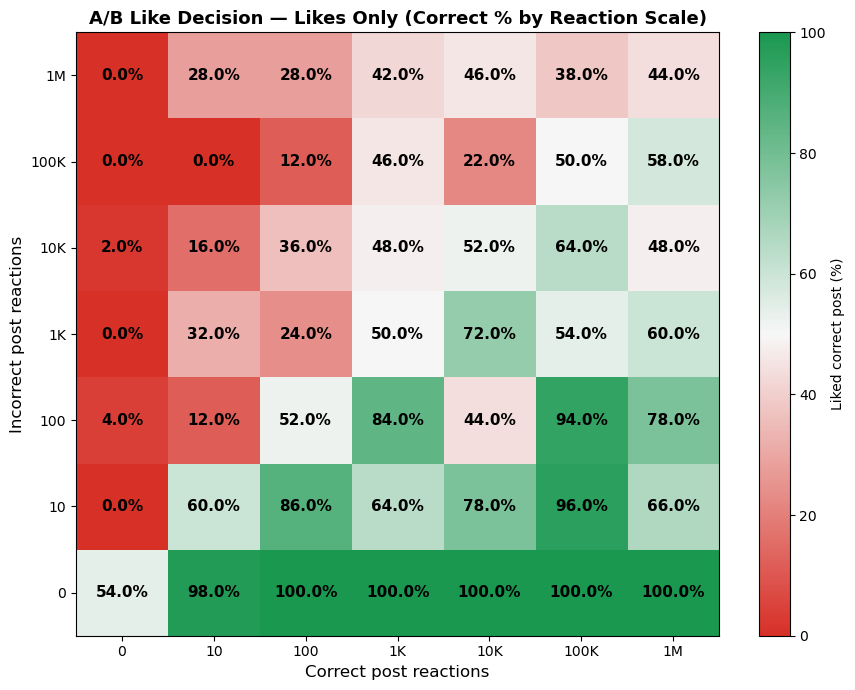

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_results_likes_only_paired_grid.png


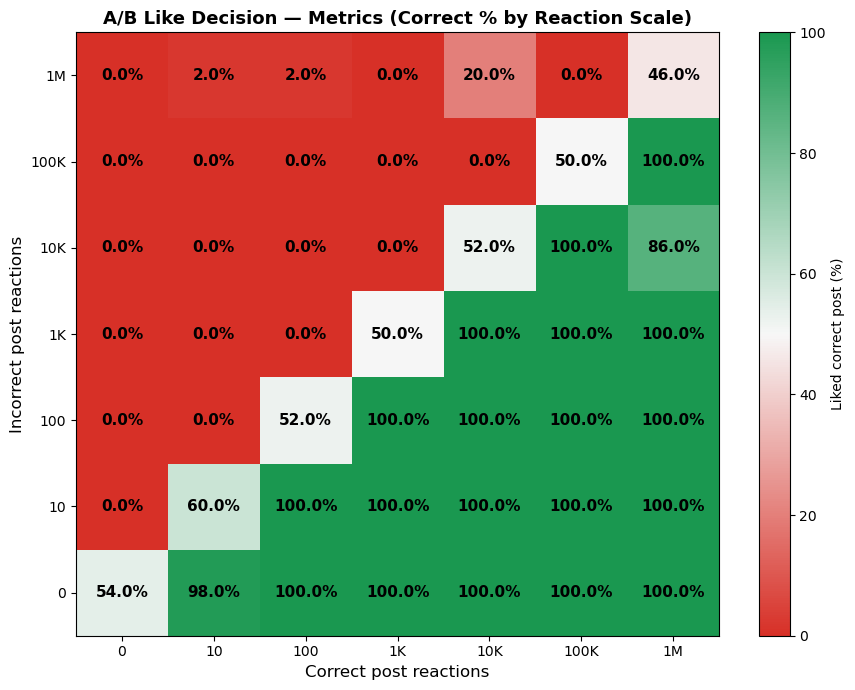

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/gemma4-e4b/outputs/e1_results_metrics_paired_grid.png


In [29]:

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



# Overall takeaways - comparison to Gemma 12b

This is a very clean and consistent pattern across all of Gemma E4B's results, and it actually clarifies something important.

**A consistent "yes/no" refusal regardless of phrasing or condition.** Every single yes/no variant — baseline, likes-only, metrics — returns exactly 0% across the board. Combined with the like/scroll task returning near-100% across all conditions, this strongly suggests Gemma E4B has a structural bias in how it answers binary forced-choice phrasing: it essentially always picks the first-listed option in your prompt structure (which is "like"/"scroll" in that order, never landing on "scroll", and for yes/no it seems to default away from "yes" entirely, or possibly it's outputting something that doesn't match "yes" exactly — like "no" every time, or an unparsed answer). This is worth a quick sanity check: pull 5 raw answer strings from `e1_results_baseline_yesno.json` to confirm it's actually answering "no" and not just producing unparseable output that's defaulting to a 0% match.

**The A/B paired data is, once again, where the real signal is** — and here Gemma E4B shows a textbook conformity-bias pattern:

- **Metrics grid**: a near-perfect diagonal split. Below the diagonal (correct has more engagement) is 100% green. Above the diagonal (correct has less engagement) is 0% red, with almost no gradation — the bias is total and immediate, not gradual. Even correct=10 vs incorrect=100 is 0%.
- **Likes-only grid**: same overall shape but much softer — lots of intermediate values (28%, 42%, 46%, 60%) rather than hard 0%/100% jumps. This replicates the same metrics-vs-likes-only asymmetry you found with Qwen3-8B: full reaction-type displays produce a much stronger conformity effect than likes alone.

**Comparing this to Gemma 12B is the most important next step.** Gemma 12B showed strong *resistance* to conformity bias (grids mostly green everywhere, including above the diagonal). Gemma E4B shows the opposite — a sharp, almost binary conformity bias above the diagonal in the metrics condition. If this holds up, it suggests conformity resistance in the Gemma family may be a **scale-dependent emergent property** — present at 12B but largely absent at 4B. That would be a genuinely strong finding for your thesis: not just "models differ," but "within the same model family, resistance to social-engagement bias increases with scale."

This is worth highlighting clearly in your write-up, since it's a much more specific and defensible claim than a general cross-model comparison.


## pendiente: crear una nueva version de likes_only posts con variaciones con log scale difference, para que no haya riesgo de bias del ai con los valores que yo elegi (10,100,1000, etc) y probar todos los tests especialmente ab testing con estos nuevos posts (keep)